# **DATA SET HOSPITAL LENGTH OF STAY**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/cmv-ia/LengthOfStay.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [ ]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [ ]:
df.columns

Index(['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma',
       'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor',
       'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
       'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
       'creatinine', 'bmi', 'pulse', 'respiration',
       'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay'],
      dtype='object')

In [ ]:
mean_length_of_stay = df['lengthofstay'].mean()
display(f"The mean length of stay is: {mean_length_of_stay:.2f} days")

'The mean length of stay is: 4.00 days'

In [ ]:
gender_length_of_stay = df.groupby('gender')['lengthofstay'].mean()
display(gender_length_of_stay)

,lengthofstay
gender,
F,3.860261
M,4.192601


✅ Dataset nettoyé enregistré : hospital_los_clean.csv


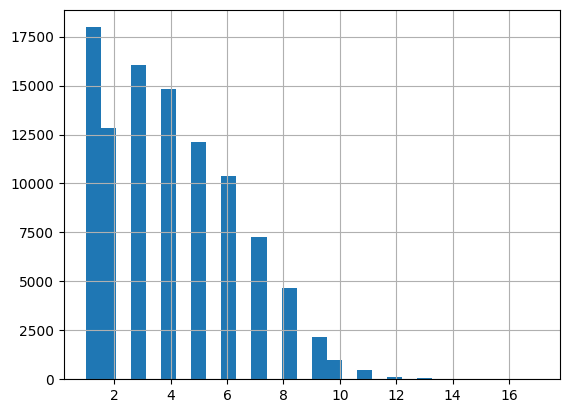

In [ ]:


# 1️⃣ Supprimer les colonnes inutiles
df = df.drop(columns=["eid", "facid"])

# 2️⃣ Convertir la date
df["vdate"] = pd.to_datetime(df["vdate"], errors="coerce")

# 3️⃣ Vérifier les doublons
df = df.drop_duplicates()

# 4️⃣ Nettoyer la cible
df = df[df["lengthofstay"].notnull()]
df = df[df["lengthofstay"] > 0]  # garder valeurs positives seulement

# 5️⃣ Normaliser le genre
df["gender"] = df["gender"].map({"M": 1, "F": 0}).astype(int)

# 6️⃣ Remplacer les NaN dans les comorbidités par 0
comorb_cols = [
    "dialysisrenalendstage", "asthma", "irondef", "pneum", "substancedependence",
    "psychologicaldisordermajor", "depress", "psychother", "fibrosisandother",
    "malnutrition", "hemo"
]
df[comorb_cols] = df[comorb_cols].fillna(0).astype(int)

# 7️⃣ Imputer les valeurs manquantes des variables continues par médiane
cont_cols = [
    "hematocrit", "neutrophils", "sodium", "glucose", "bloodureanitro",
    "creatinine", "bmi", "pulse", "respiration"
]
for col in cont_cols:
    df[col] = df[col].fillna(df[col].median())

# 8️⃣ Supprimer ou encoder les colonnes ambiguës
df["secondarydiagnosisnonicd9"] = df["secondarydiagnosisnonicd9"].fillna("none")

# 9️⃣ (optionnel) Vérifier la distribution de la cible
df["lengthofstay"].hist(bins=30)

# 10️⃣ Export dataset propre
df.to_csv("hospital_los_clean.csv", index=False)
print("✅ Dataset nettoyé enregistré : hospital_los_clean.csv")

In [ ]:
df['lengthofstay'].value_counts()

,count
lengthofstay,
1,17979
3,16068
4,14822
2,12825
5,12116
6,10362
7,7263
8,4652
9,2184
